# [LAB-07] 9. 상관분석의 이해

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helper import *
from pandas import DataFrame

import numpy as np
from scipy.stats import pearsonr, spearmanr

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

In [2]:
origin = load_data('language_math_scores')
origin.head()

📚 어느 학급의 언어영역과 수리영역 점수를 기록한 가상의 데이터 셋


,언어영역,수리영역
0,66,66
1,58,70
2,73,74
3,52,58
4,72,79


## #02. 시각화를 통한 상관정도 확인

### 1. 산점도 그래프 시각화

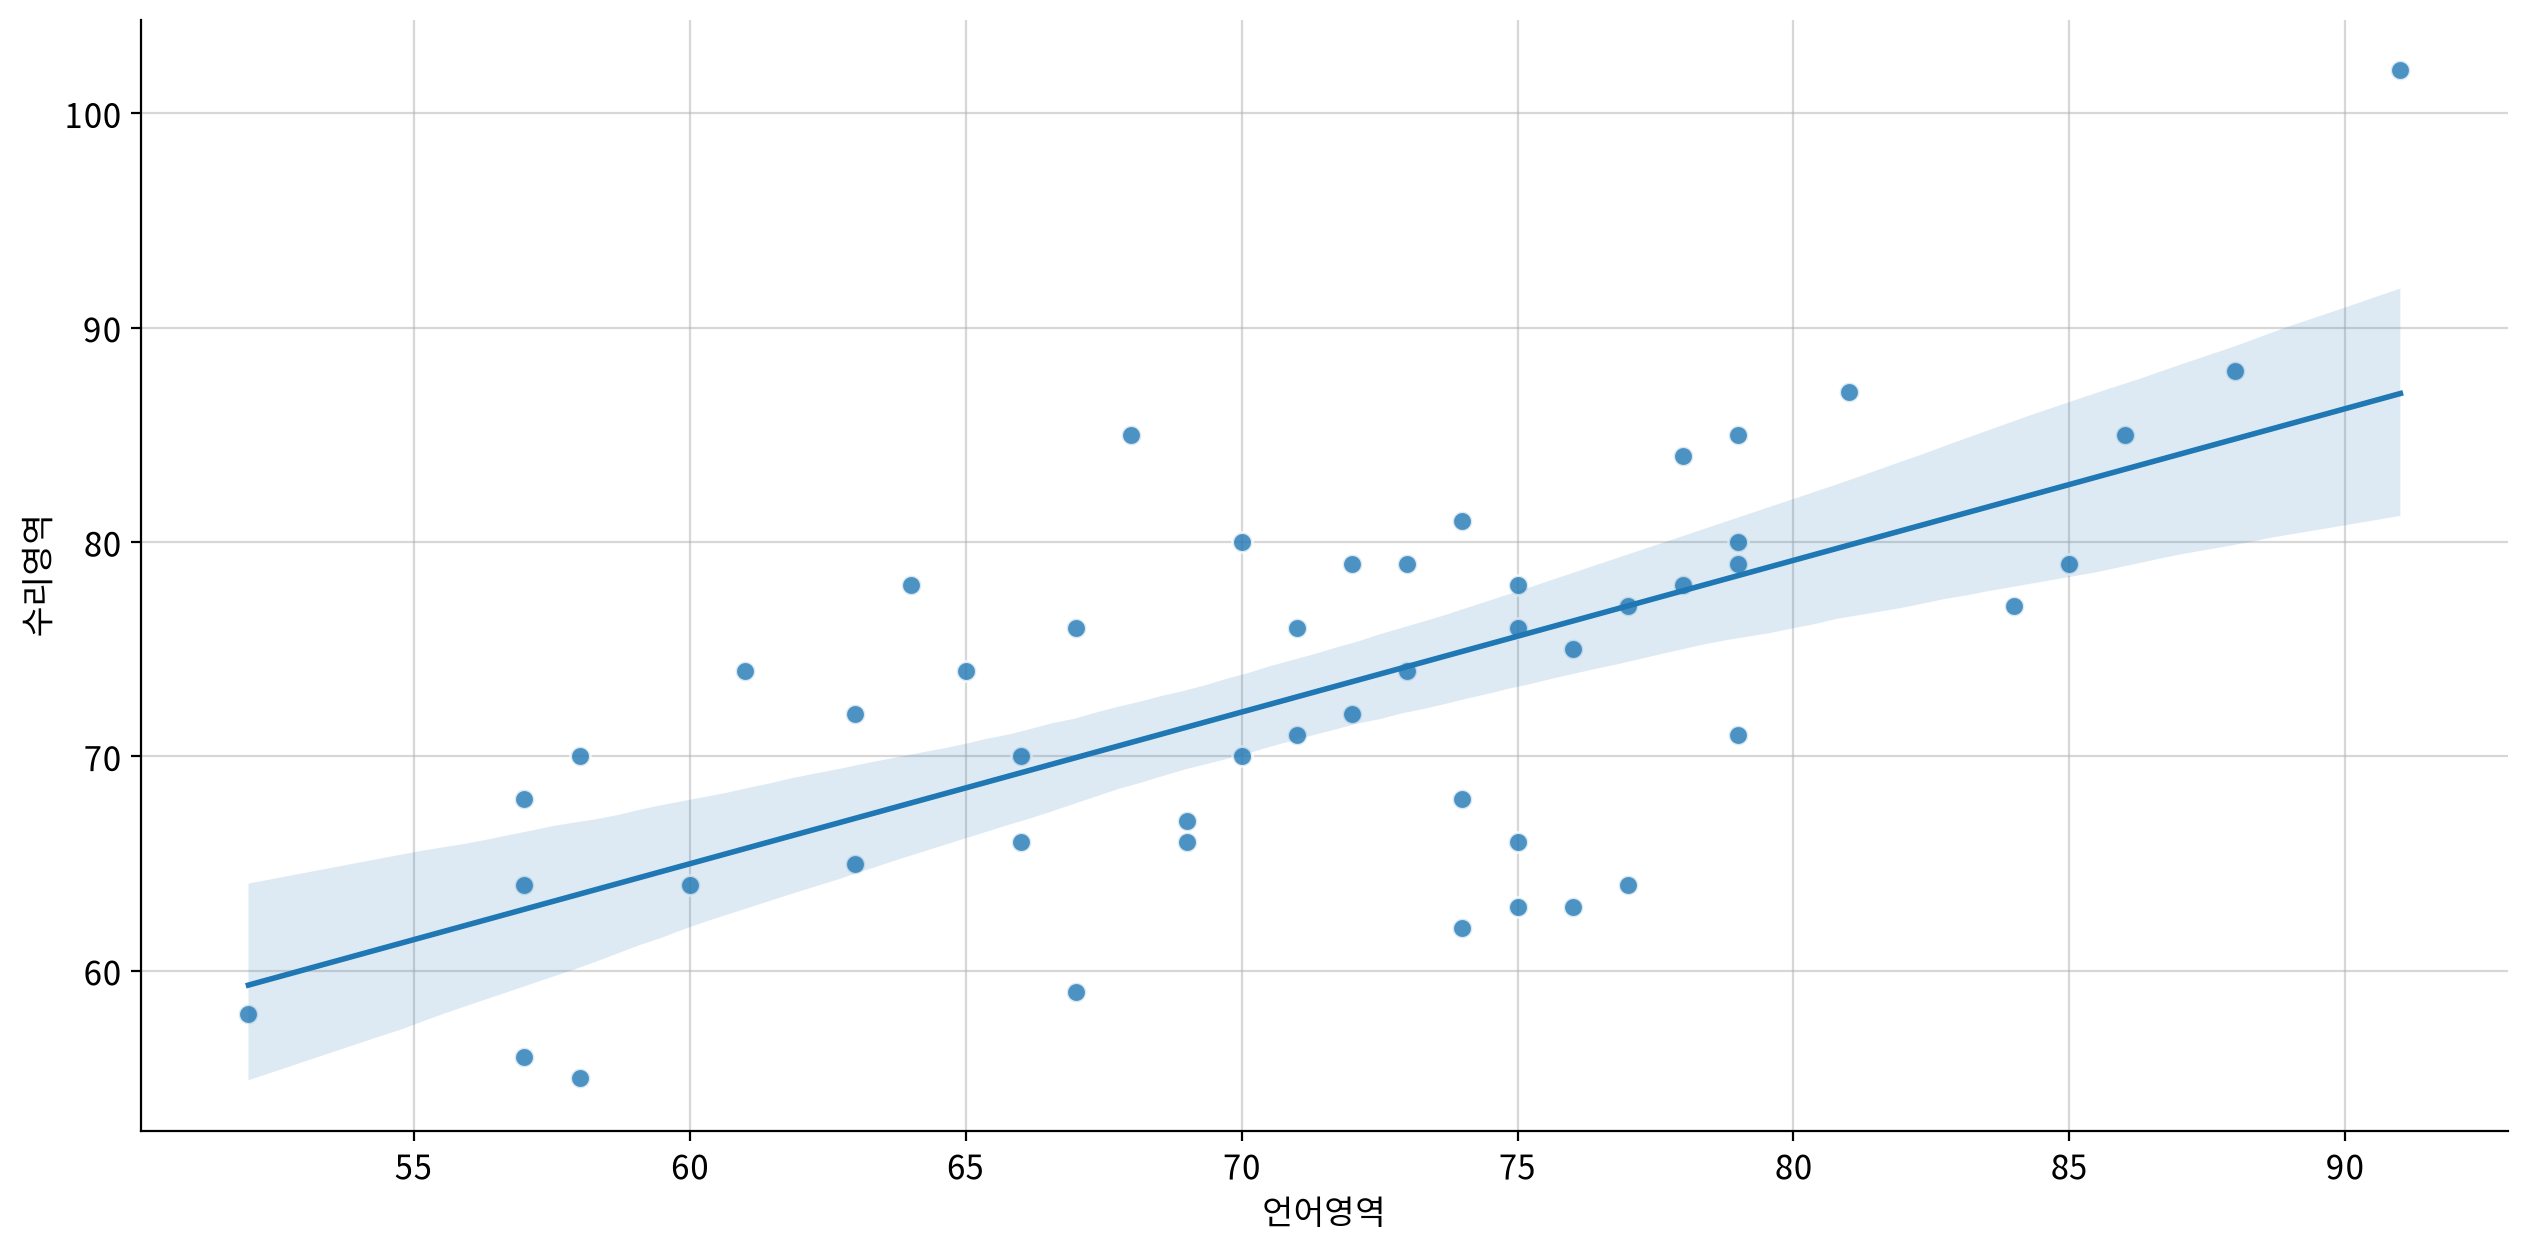

In [3]:
my_plot.lmplot(origin, x='언어영역', y='수리영역')

#### 💡 인사이트

- 📈 언어영역 점수가 높을수록 수리영역 점수도 함께 높아지는 경향이 있음
- 📏 두 변수는 대체로 직선적인 관계를 보임
- 🌫️ 다만 점들이 넓게 퍼져 있어 관계가 아주 강하다고 보긴 어려움
- 🔎 일부 벗어난 점도 보여서 해석할 때 같이 봐야 함

## #03. 공분산

### 1. 공분산 행렬 구하기

- 파이썬에서는 numpy 패키지의 **cov() 함수**를 사용하여 공분산 값을 구할 수 있다.
  - 2차원 배열이 리턴되는데 이 중에서 공분산 값은 `0행1열` 혹은 `1행0열`의 값이다.
- 공분산은 상관관계의 상승 혹은 하강하는 경향을 이해할 수는 있으나 2개 변수의 측정 단위의 크기에 따라 값이 달라지므로 절대적 정도를 파악하기에는 한계가 있다.
  - 결과값이 양수면 정비례, 음수면 반비례

> 그래서 잘 안쓴다.

In [4]:
c = np.cov(origin['언어영역'], origin['수리영역'])
c

array([[76.86693878, 54.39020408],
       [54.39020408, 85.57714286]])

### 2. 공분산 해석

#### (1) 부호

| 부호 | 설명 |
|---|---|
| `+` | 두 변수가 같은 방향으로 변화 (하나가 증가하면 다른 하나도 증가) |
| `-` | 두 변수가 반대방향으로 변화 (하나가 증가하면 다른 하나는 감소) |

#### (2) 크기

- 공분산이 `0`이라도 완전히 독립이라고 단정할 수는 없다. (비선형 관계일 수 있음)
- 공분산의 크기가 클 수록 두 변수는 함께 많이 변화하며 단위에 따라 공분산의 크기가 달라지므로 절대적 크기로 판단이 어려움
- 공분산은 선형적인 관계를 측정하기 때문에 두 변수가 비선형적으로 함께 변하는 경우는 잘 측정하지 못함


#### (3) 공분산을 꼭 알아야 할까?

- **실무 계산만 한다면 필수는 아님**: 라이브러리(`pandas.corr`, `numpy.cov`)가 대신 계산해주기 때문에 공식을 직접 외우지 않아도 된다.
- **이해도는 확실히 높여줌**: 공분산이 양수/음수/0일 때 의미, 단위의 영향을 받는다는 점을 알면 상관계수가 왜 `-1~1`로 정규화되는지, 왜 단위에 무관한지를 직관적으로 잡을 수 있다.
- **추천**: 공분산의 개념과 해석(부호·단위 의존성) 정도는 짧게 익히고, 계산은 도구에 맡겨도 충분하다.

## #04. 상관분석

### 1. 피어슨 상관계수

| \|r\| 구간 | 강도 (통일 용어) |
|---|---|
| \|r\| > 0.7 | Strong (강함) |
| 0.3 < \|r\| ≤ 0.7 | Moderate (중간) |
| 0 < \|r\| ≤ 0.3 | Weak (약함) |
| r ≈ 0 | None (없음) |

In [11]:
# pearson
pearson_p, pearson_r = pearsonr(x=origin["언어영역"], y=origin["수리영역"])
print(f'Pearson correlation coefficient: {pearson_r: .4f}, p-value{pearson_p: .4f}')

Pearson correlation coefficient:  0.0000, p-value 0.6706


#### 💡 인사이트

- 📈 피어슨 상관계수 0.6706으로, 두 변수는 **양의 상관관계**가 있음
- 🔍 p-value가 0.0000이라 **통계적으로 유의함**
- 📏 상관 정도는 위 강도 기준표에 따라 **중간(Moderate)** 수준임 (|r|이 0.7을 넘지 않음)

### 2. 스피어만 상관계수

- 여기서는 코드의 전개 방법을 위해 제시함

In [12]:
spearman_r, spearman_p = spearmanr(origin["언어영역"], origin["수리영역"])
print(f"Spearman correlation coefficient: {spearman_r:.4f}, p-value: {spearman_p:.4f}")

Spearman correlation coefficient: 0.5991, p-value: 0.0000


#### 💡 인사이트

- 📈 스피어만 상관계수 0.5991로, 두 변수는 양의 상관관계가 있음
- 🔍 p-value 0.0000이라 통계적으로 유의함
- 📏 순위 기준으로도 중간 정도의 관련성이 보임

### 3. 상관행렬

여러 변수들 간의 상관계수를 한눈에 볼 수 있도록 정리한 표

#### 특징
- 행과 열에 같은 변수들이 배치
- 대각선 값은 항상 $1$ (자기 자신과의 상관계수)
- 대칭 행렬입니다 (A와 B의 상관계수 = B와 A의 상관계수)

#### 해석 방법
- **1에 가까울수록**: 강한 양의 상관관계 (한 변수가 증가하면 다른 변수도 증가)
- **-1에 가까울수록**: 강한 음의 상관관계 (한 변수가 증가하면 다른 변수는 감소)
- **0에 가까울수록**: 상관관계가 없음 (두 변수는 서로 독립적)

In [13]:
# 분석 대상 변수명 정의 (이후 셀에서 공통으로 사용)
xname = '언어영역'
yname = '수리영역'

# method='pearson' or 'spearman'
matrix = origin[[xname, yname]].corr(method='pearson')
matrix

,언어영역,수리영역
언어영역,1.000,0.671
수리영역,0.671,1.000


### 4. 상관계수 히트맵

상관행렬을 시각화한 그래프

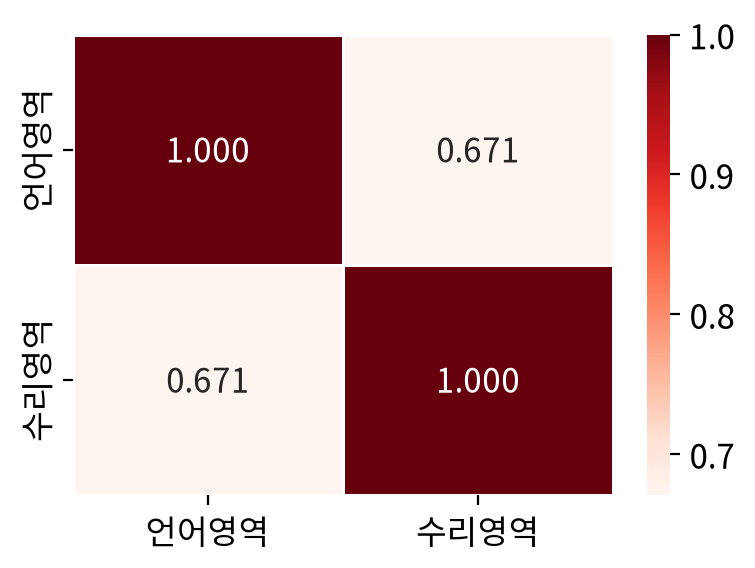

In [14]:
my_plot.heatmap(matrix, width=400, height=300, palette='Reds', annot=True, fmt=".3f")

### 5. 상관행렬에 직접 배경색상 적용

In [15]:
matrix.style.background_gradient(cmap='Reds')

,언어영역,수리영역
언어영역,1.000000,0.670613
수리영역,0.670613,1.000000


> 여기까지는 쉽다.